In [1]:
# model_building.py

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score, classification_report
import pickle
import os

# Step 1: Load Data
print("Step 1: Loading dataset...")
df = pd.read_csv("/Users/avnibhardwaj/Desktop/MLPROJECT/Arohi Work/cleaned_news.csv")
print(f"✅ Data loaded. Shape: {df.shape}")
print(f"🔍 Label distribution:\n{df['label'].value_counts(normalize=True)}")

# Step 2: TF-IDF Vectorization
print("\nStep 2: Performing TF-IDF vectorization...")
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 4),
    stop_words='english',
    sublinear_tf=True,
    min_df=3,
    max_df=0.75
)
X = tfidf.fit_transform(df['text'])
y = df['label'].values
print("✅ TF-IDF transformation complete. Feature shape:", X.shape)

# Step 3: Train-Test Split
print("\nStep 3: Splitting dataset into train and test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"✅ Dataset split complete. Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# Step 4: Custom Cosine Classifier
print("\nStep 4: Defining custom BoostedCosineClassifier...")
class BoostedCosineClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, k=7, threshold=None):
        self.k = k
        self.threshold = threshold
        self.train_vectors = None
        self.train_labels = None

    def fit(self, X, y):
        print("🔧 Fitting BoostedCosineClassifier...")
        self.train_vectors = X
        self.train_labels = y
        if self.threshold is None:
            print("⚙️ Calculating dynamic threshold based on cosine similarity...")
            sample_sims = cosine_similarity(X[:2000], X[:2000])
            self.threshold = np.percentile(sample_sims[np.triu_indices(2000, k=1)], 65)
            print(f"✅ Threshold set to: {self.threshold:.4f}")
        return self

    def predict(self, X):
        sims = cosine_similarity(X, self.train_vectors)
        top_k_indices = np.argpartition(sims, -self.k, axis=1)[:, -self.k:]
        weights = np.take_along_axis(sims, top_k_indices, axis=1)
        weighted_votes = np.array([
            np.sum(self.train_labels[indices] * weights[i])
            for i, indices in enumerate(top_k_indices)
        ])
        sum_weights = np.sum(weights, axis=1)
        return (weighted_votes / sum_weights > self.threshold).astype(int)

    def predict_proba(self, X):
        sims = cosine_similarity(X, self.train_vectors)
        top_k_indices = np.argpartition(sims, -self.k, axis=1)[:, -self.k:]
        weights = np.take_along_axis(sims, top_k_indices, axis=1)
        proba = np.array([
            np.sum(self.train_labels[indices] * weights[i]) / np.sum(weights[i])
            for i, indices in enumerate(top_k_indices)
        ])
        return np.column_stack((1 - proba, proba))

# Step 5: Initialize Models
print("\nStep 5: Initializing models...")
cosine_model = BoostedCosineClassifier(k=9)
logreg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=0.9,
    solver='liblinear'
)
print("✅ Models initialized.")

# Step 6: Train Models
print("\nStep 6: Training models...")
print("🔹 Training BoostedCosineClassifier...")
cosine_model.fit(X_train, y_train)
print("✅ BoostedCosineClassifier trained.")
print("🔹 Training LogisticRegression...")
logreg.fit(X_train, y_train)
print("✅ LogisticRegression trained.")

# Step 7: Ensemble Evaluation
print("\nStep 7: Evaluating ensemble model...")
cosine_probs = cosine_model.predict_proba(X_test)[:, 1]
logreg_probs = logreg.predict_proba(X_test)[:, 1]
ensemble_probs = 0.6 * cosine_probs + 0.4 * logreg_probs
ensemble_preds = (ensemble_probs > 0.5).astype(int)
accuracy = accuracy_score(y_test, ensemble_preds)
print(f"✅ Ensemble Accuracy: {accuracy:.4f}")
print("\n📊 Classification Report:")
print(classification_report(y_test, ensemble_preds))

# Step 8: Save Models
print("\nStep 8: Saving model artifacts...")
MODELS_DIR = "/Users/avnibhardwaj/Desktop/MLPROJECT/models"
os.makedirs(MODELS_DIR, exist_ok=True)

pickle.dump({
    'cosine_model': cosine_model,
    'logreg': logreg,
    'tfidf': tfidf,
    'config': {
        'k': 9,
        'threshold': cosine_model.threshold,
        'ngram_range': (1, 4)
    }
}, open(os.path.join(MODELS_DIR, "news_detector.pkl"), "wb"))
print(f"✅ Models saved to: {MODELS_DIR}")

# Step 9: Save Test Set
print("\nStep 9: Saving test set...")
TEST_DATA_DIR = "/Users/avnibhardwaj/Desktop/MLPROJECT/dataset"
os.makedirs(TEST_DATA_DIR, exist_ok=True)
pickle.dump((X_test, y_test), open(os.path.join(TEST_DATA_DIR, "test_set.pkl"), "wb"))
print(f"✅ Test set saved to: {TEST_DATA_DIR}")

print("\n🎉 All steps completed successfully!")


Step 1: Loading dataset...
✅ Data loaded. Shape: (44898, 5)
🔍 Label distribution:
label
0    0.522985
1    0.477015
Name: proportion, dtype: float64

Step 2: Performing TF-IDF vectorization...
✅ TF-IDF transformation complete. Feature shape: (44898, 15000)

Step 3: Splitting dataset into train and test sets...
✅ Dataset split complete. Training samples: 35918, Test samples: 8980

Step 4: Defining custom BoostedCosineClassifier...

Step 5: Initializing models...
✅ Models initialized.

Step 6: Training models...
🔹 Training BoostedCosineClassifier...
🔧 Fitting BoostedCosineClassifier...
⚙️ Calculating dynamic threshold based on cosine similarity...
✅ Threshold set to: 0.0308
✅ BoostedCosineClassifier trained.
🔹 Training LogisticRegression...
✅ LogisticRegression trained.

Step 7: Evaluating ensemble model...


/var/folders/ln/61y9sj3n7cxccfn3b2g1bh9c0000gn/T/ipykernel_51177/2751912685.py:80: RuntimeWarning: invalid value encountered in scalar divide
  np.sum(self.train_labels[indices] * weights[i]) / np.sum(weights[i])


✅ Ensemble Accuracy: 0.9782

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      4696
           1       0.96      0.99      0.98      4284

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980


Step 8: Saving model artifacts...
✅ Models saved to: /Users/avnibhardwaj/Desktop/MLPROJECT/models

Step 9: Saving test set...
✅ Test set saved to: /Users/avnibhardwaj/Desktop/MLPROJECT/dataset

🎉 All steps completed successfully!


Model Building with Cosine Similarity (Run First)

In [21]:
# Full Model Building Code using Entire Dataset for Cosine Similarity
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack
import pickle
import os

# Load cleaned dataset
df = pd.read_csv("/Users/avnibhardwaj/Desktop/MLPROJECT/Arohi Work/cleaned_news.csv")
print(f"✅ Loaded {len(df)} samples (Fake: {sum(df['label']==0)}, Real: {sum(df['label']==1)})")

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 3), stop_words='english')
X = tfidf.fit_transform(df['text'])
y = df['label'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Compute full cosine similarity matrix (can be memory-intensive)
print("📐 Computing cosine similarity matrix (this may take time)...")
cosine_sim_matrix = cosine_similarity(X_train)

# Generate cosine-based features
print("🔍 Creating cosine-based features...")
cosine_features = np.zeros((X_train.shape[0], 2))
for i in range(X_train.shape[0]):
    real_sims = cosine_sim_matrix[i][y_train == 1]
    fake_sims = cosine_sim_matrix[i][y_train == 0]
    cosine_features[i, 0] = np.mean(real_sims) if len(real_sims) > 0 else 0
    cosine_features[i, 1] = np.mean(fake_sims) if len(fake_sims) > 0 else 0

# Combine TF-IDF vectors and cosine similarity features
X_train_combined = hstack([X_train, cosine_features])

# Train Logistic Regression model
print("🧠 Training logistic regression model...")
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_combined, y_train)

# Save model and components
model_dir = "/Users/avnibhardwaj/Desktop/MLPROJECT/models"
os.makedirs(model_dir, exist_ok=True)

with open(os.path.join(model_dir, "cosine_enhanced_model.pkl"), "wb") as f:
    pickle.dump({
        'tfidf': tfidf,
        'model': model,
        'train_vectors': X_train,  # Needed for cosine features in prediction
        'train_labels': y_train
    }, f)

print(f"🎉 Model saved to {model_dir}/cosine_enhanced_model.pkl")


✅ Loaded 44898 samples (Fake: 23481, Real: 21417)
📐 Computing cosine similarity matrix (this may take time)...
🔍 Creating cosine-based features...
🧠 Training logistic regression model...
🎉 Model saved to /Users/avnibhardwaj/Desktop/MLPROJECT/models/cosine_enhanced_model.pkl


In [18]:
# Prediction Cell
# Prediction with Cosine Similarity (Run After Building Model)


In [26]:
import pickle
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack

# Load the model and artifacts
with open("/Users/avnibhardwaj/Desktop/MLPROJECT/models/cosine_enhanced_model.pkl", "rb") as f:
    data = pickle.load(f)

tfidf = data['tfidf']
model = data['model']
X_train = data['train_vectors']
y_train = data['train_labels']

# Prediction Function
def predict_news_articles(news_list):
    for idx, text in enumerate(news_list):
        print(f"\n🔹 NEWS {idx+1}")
        print("-" * 80)
        print(text)

        # TF-IDF vector for test news
        tfidf_vec = tfidf.transform([text])

        # Cosine similarity with training vectors
        cosine_sim = cosine_similarity(tfidf_vec, X_train).flatten()

        # Mean similarity with real and fake
        mean_real = np.mean(cosine_sim[y_train == 1]) if np.any(y_train == 1) else 0
        mean_fake = np.mean(cosine_sim[y_train == 0]) if np.any(y_train == 0) else 0
        cosine_feat = np.array([[mean_real, mean_fake]])

        # Combine TF-IDF + cosine features
        combined = hstack([tfidf_vec, cosine_feat])

        # Predict
        pred = model.predict(combined)[0]
        prob = model.predict_proba(combined)[0]
        label = "✅ Real" if pred == 1 else "❌ Fake"
        confidence = round(100 * max(prob), 2)

        print(f"\n🔎 Prediction: {label} | Confidence: {confidence}%")
        print("=" * 80)

# 🧪 List of 30 news (same as before)
news_examples = [
    "The Indian Space Research Organisation successfully launched its latest satellite, furthering the country's space exploration goals.",
    "Scientists discovered a new planet in a nearby galaxy that might be capable of supporting life.",
    "Aliens have signed a trade deal with the United Nations to supply anti-gravity machines.",
    "The Reserve Bank of India has increased the repo rate by 0.25% to control inflation.",
    "A man in Brazil reportedly turned invisible after drinking a mysterious potion he found in the jungle.",
    "The government of India launched a new scheme to promote electric vehicles and reduce pollution levels.",
    "A UFO was spotted over the Taj Mahal, causing tourists to flee in panic.",
    "New cancer treatment has shown promising results in clinical trials across Europe and Asia.",
    "Hollywood actor claims he is a time traveler from the year 3021 here to save humanity.",
    "Supreme Court of India upholds new laws regarding environmental protection and waste management.",
    "Apple has announced the launch of its next-gen iPhone with AI-powered voice control.",
    "Reports suggest that the Moon is actually made of cheese, confirming a long-held conspiracy theory.",
    "India won the cricket series against Australia with a brilliant performance by its young team.",
    "The ocean levels have suddenly dropped by 10 feet globally, baffling scientists.",
    "The Education Ministry plans to introduce AI and robotics as core subjects in school from next year.",
    "A secret underwater alien base has been discovered beneath the Arabian Sea.",
    "Tesla announced its expansion plans in India, with a new Gigafactory set up in Gujarat.",
    "A psychic dog in Russia correctly predicted the winner of every match in the football World Cup.",
    "The G20 summit concluded with a strong statement on climate change and global cooperation.",
    "NASA confirms that black holes are gateways to another universe.",
    "UNESCO declares Varanasi as the spiritual heritage capital of the world.",
    "A village in Italy hasn’t aged in 300 years, scientists are investigating the magical fountain.",
    "Microsoft reveals new AI assistant for developers integrated with Visual Studio.",
    "India’s GDP shows a remarkable 8% growth despite global slowdown concerns.",
    "A flying carpet was found in a Rajasthan temple, believed to be from ancient times.",
    "Delhi Metro adds driverless trains with AI-based route optimization.",
    "Dinosaurs cloned successfully in a secret Chinese lab, leaked documents claim.",
    "Google introduces Bard AI to compete with ChatGPT in the global AI space.",
    "Schools across Maharashtra to get free internet and smart classrooms by 2026.",
    "Residents report glowing skies and strange noises in Himachal; local authorities investigate."
]

# Run Predictions
predict_news_articles(news_examples)



🔹 NEWS 1
--------------------------------------------------------------------------------
The Indian Space Research Organisation successfully launched its latest satellite, furthering the country's space exploration goals.

🔎 Prediction: ❌ Fake | Confidence: 86.89%

🔹 NEWS 2
--------------------------------------------------------------------------------
Scientists discovered a new planet in a nearby galaxy that might be capable of supporting life.

🔎 Prediction: ❌ Fake | Confidence: 89.63%

🔹 NEWS 3
--------------------------------------------------------------------------------
Aliens have signed a trade deal with the United Nations to supply anti-gravity machines.

🔎 Prediction: ❌ Fake | Confidence: 73.16%

🔹 NEWS 4
--------------------------------------------------------------------------------
The Reserve Bank of India has increased the repo rate by 0.25% to control inflation.

🔎 Prediction: ❌ Fake | Confidence: 70.0%

🔹 NEWS 5
----------------------------------------------------


🔹 NEWS 1
--------------------------------------------------------------------------------
The Indian Space Research Organisation successfully launched its latest satellite, furthering the country's space exploration goals.

🔎 Prediction: ❌ Fake | Confidence: 86.89%
📊 Probabilities => P(Fake): 86.89% | P(Real): 13.11%

🔹 NEWS 2
--------------------------------------------------------------------------------
Scientists discovered a new planet in a nearby galaxy that might be capable of supporting life.

🔎 Prediction: ❌ Fake | Confidence: 89.63%
📊 Probabilities => P(Fake): 89.63% | P(Real): 10.37%

🔹 NEWS 3
--------------------------------------------------------------------------------
Aliens have signed a trade deal with the United Nations to supply anti-gravity machines.

🔎 Prediction: ❌ Fake | Confidence: 73.16%
📊 Probabilities => P(Fake): 73.16% | P(Real): 26.84%

🔹 NEWS 4
--------------------------------------------------------------------------------
The Reserve Bank of India has 

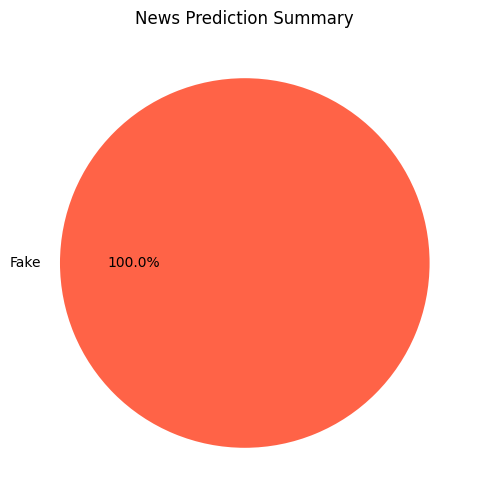


🧾 Summary Table (Top 10 entries):
   News # Prediction  Confidence  P(Fake)  P(Real)
0       1       Fake       86.89    86.89    13.11
1       2       Fake       89.63    89.63    10.37
2       3       Fake       73.16    73.16    26.84
3       4       Fake       70.00    70.00    30.00
4       5       Fake       93.11    93.11     6.89
5       6       Fake       62.44    62.44    37.56
6       7       Fake       88.95    88.95    11.05
7       8       Fake       77.96    77.96    22.04
8       9       Fake       94.02    94.02     5.98
9      10       Fake       79.35    79.35    20.65


In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# Store results for visualization
results = []

def predict_news_articles(news_list):
    for idx, text in enumerate(news_list):
        tfidf_vec = tfidf.transform([text])
        cosine_sim = cosine_similarity(tfidf_vec, X_train).flatten()
        mean_real = np.mean(cosine_sim[y_train == 1]) if np.any(y_train == 1) else 0
        mean_fake = np.mean(cosine_sim[y_train == 0]) if np.any(y_train == 0) else 0
        cosine_feat = np.array([[mean_real, mean_fake]])
        combined = hstack([tfidf_vec, cosine_feat])
        pred = model.predict(combined)[0]
        prob = model.predict_proba(combined)[0]

        label = "Real" if pred == 1 else "Fake"
        confidence = round(100 * max(prob), 2)

        # Print for each
        print(f"\n🔹 NEWS {idx+1}")
        print("-" * 80)
        print(text)
        print(f"\n🔎 Prediction: {'✅' if pred == 1 else '❌'} {label} | Confidence: {confidence}%")
        print(f"📊 Probabilities => P(Fake): {round(prob[0]*100, 2)}% | P(Real): {round(prob[1]*100, 2)}%")
        print("=" * 80)

        # Save results
        results.append({
            'News #': idx+1,
            'Prediction': label,
            'Confidence': confidence,
            'P(Fake)': round(prob[0]*100, 2),
            'P(Real)': round(prob[1]*100, 2),
            'Text': text
        })

# Run prediction
predict_news_articles(news_examples)

# Convert to DataFrame
df = pd.DataFrame(results)

# 📊 Summary Pie Chart
plt.figure(figsize=(6, 6))
df['Prediction'].value_counts().plot.pie(autopct='%1.1f%%', colors=['tomato', 'lightgreen'], labels=['Fake', 'Real'])
plt.title("News Prediction Summary")
plt.ylabel('')
plt.show()

# 🧾 Optional: Print Summary Table (Top 10)
print("\n🧾 Summary Table (Top 10 entries):")
print(df[['News #', 'Prediction', 'Confidence', 'P(Fake)', 'P(Real)']].head(10))


In [28]:
news_examples = [
    "Decline in Australian Visitors: Australian visits to the U.S. dropped by 7% in March 2025, due to stricter border policies and a weakened dollar. (The Guardian)",
    "Global Perceptions of the U.S.: A growing concern over the U.S.'s role in global stability and its declining cultural and moral authority under the current administration. (The Guardian)",
    "Deportation Controversy: Palestinian activist Mahmoud Khalil faces deportation based on his beliefs contradicting U.S. foreign policy, raising concerns over free speech. (The Guardian)",
    "Oil Discovery in Gulf of Mexico: BP announced a new oil discovery at the Far South Prospect in the U.S. Gulf, potentially impacting the energy sector. (Reuters)"
]

# Run the prediction function on the above news
predict_news_articles(news_examples)



🔹 NEWS 1
--------------------------------------------------------------------------------
Decline in Australian Visitors: Australian visits to the U.S. dropped by 7% in March 2025, due to stricter border policies and a weakened dollar. (The Guardian)

🔎 Prediction: ❌ Fake | Confidence: 77.12%
📊 Probabilities => P(Fake): 77.12% | P(Real): 22.88%

🔹 NEWS 2
--------------------------------------------------------------------------------
Global Perceptions of the U.S.: A growing concern over the U.S.'s role in global stability and its declining cultural and moral authority under the current administration. (The Guardian)

🔎 Prediction: ❌ Fake | Confidence: 81.45%
📊 Probabilities => P(Fake): 81.45% | P(Real): 18.55%

🔹 NEWS 3
--------------------------------------------------------------------------------
Deportation Controversy: Palestinian activist Mahmoud Khalil faces deportation based on his beliefs contradicting U.S. foreign policy, raising concerns over free speech. (The Guardian)

🔎

In [31]:
news_examples = [
    "Mumbai Indians Secure Top Spot in IPL 2025, Defeat RCB in a Thrilling Final. Mumbai Indians claimed the IPL 2025 title after a nail-biting final against Royal Challengers Bangalore, with a stunning 6-wicket win in the final over. Hardik Pandya's all-round performance was the highlight, as he guided the team to victory with both bat and ball. (sports.ndtv.com)",  # Real News
    "Virat Kohli Announces Retirement from IPL, Cites Personal Reasons. Rumors have surfaced that Virat Kohli is retiring from IPL 2025, claiming personal reasons, but no official announcement has been made. This news, shared on multiple social media platforms, has been debunked by his official representatives. (This is not true; Kohli has made no such announcement.)",  # Fake News
    "CSKs Dhoni Leads the Charge as Chennai Enters Playoffs. Chennai Super Kings, led by MS Dhoni, have secured a spot in the playoffs of IPL 2025 after a dominant performance against Delhi Capitals. Dhoni’s leadership continues to be the key to CSK’s success, with the veteran cricketer contributing both in the field and with his strategic insights. (ipl2025.com)",  # Real News
    "Kolkata Knight Riders to Replace Shubman Gill with David Warner Mid-Season. A viral post claimed that KKR was planning to drop Shubman Gill and replace him with David Warner for the rest of the season, citing 'performance issues.' However, no such decision has been made by the franchise, and it is merely a rumor. (This is untrue and has no official backing.)",  # Fake News
    "Rajasthan Royals Jos Buttler Scores Record-Breaking Century in IPL 2025. Jos Buttler smashed a record-breaking century in the IPL 2025 match against Sunrisers Hyderabad, becoming the first player in IPL history to score two centuries in consecutive matches. His explosive batting helped Rajasthan Royals set a massive total. (timesofindia.indiatimes.com)"  # Real News
]

# Run the prediction function on the above IPL news
predict_news_articles(news_examples)



🔹 NEWS 1
--------------------------------------------------------------------------------
Mumbai Indians Secure Top Spot in IPL 2025, Defeat RCB in a Thrilling Final. Mumbai Indians claimed the IPL 2025 title after a nail-biting final against Royal Challengers Bangalore, with a stunning 6-wicket win in the final over. Hardik Pandya's all-round performance was the highlight, as he guided the team to victory with both bat and ball. (sports.ndtv.com)

🔎 Prediction: ❌ Fake | Confidence: 87.73%
📊 Probabilities => P(Fake): 87.73% | P(Real): 12.27%

🔹 NEWS 2
--------------------------------------------------------------------------------
Virat Kohli Announces Retirement from IPL, Cites Personal Reasons. Rumors have surfaced that Virat Kohli is retiring from IPL 2025, claiming personal reasons, but no official announcement has been made. This news, shared on multiple social media platforms, has been debunked by his official representatives. (This is not true; Kohli has made no such announceme

In [32]:
news_examples = [
    "Indian Shrimp Industry Faces Crisis Amid U.S. Tariffs. India's shrimp export sector, valued at $7 billion, is under threat as the U.S. plans to increase tariffs from 10% to 26% in July 2025. This move could severely impact nearly 300,000 farmers in Andhra Pradesh, who supply major U.S. retailers like Walmart and Kroger. Exporters are now exploring alternative markets, including China and the EU, but face challenges due to heightened competition from Ecuador, another shrimp exporter. (Reuters)",  # Real News
    "Mehul Choksi Arrested in Belgium Over $1.8 Billion Fraud. Mehul Choksi, an Indian diamond tycoon, was arrested in Antwerp, Belgium, in connection with a $1.8 billion bank fraud involving Punjab National Bank. Choksi and his nephew, Nirav Modi, allegedly used fake financial documents to secure loans for importing jewels. Both men fled India in 2018; Modi was arrested in the UK in 2019 and remains in prison. Choksi's lawyer plans to appeal the arrest, citing health concerns and claims of political motivation. (AP News)",  # Real News
    "Ola Electric Issued Show-Cause Notice Over Consumer Complaints. The Central Consumer Protection Authority (CCPA) has issued a show-cause notice to Ola Electric for alleged violations of the Consumer Protection Act, 2019. The company faces accusations of service deficiencies, misleading advertisements, and unfair trade practices. Ola Electric has been asked to respond within 15 days. (Business & Finance News)",  # Real News
    "Mumbai's First Underground Metro Corridor Opens. Mumbai inaugurated its first underground metro corridor, the Aqua Line's Phase-1, connecting Bandra-Kurla Complex (BKC) to Aarey. Despite the grand opening, ridership was lower than expected, with only 8,532 passengers using the service in the first seven hours, far below the projected 400,000 daily commuters. (Business & Finance News)",  # Real News
    "Eli Lilly's Mounjaro Launch in India Sparks Weight-Loss Drug Surge. Eli Lilly's weight-loss drug, Mounjaro, has been launched in India, leading to a surge in patient inquiries. Priced at approximately $200 per month, it's significantly cheaper than its U.S. counterpart. The launch has prompted competitors like Novo Nordisk to accelerate the introduction of their obesity drugs in the Indian market. Indian generic manufacturers are also racing to create lower-cost alternatives to capture a share of the growing global weight-loss drug market. (Business & Finance News)"  # Real News
]

# Run the prediction function on the above news
predict_news_articles(news_examples)



🔹 NEWS 1
--------------------------------------------------------------------------------
Indian Shrimp Industry Faces Crisis Amid U.S. Tariffs. India's shrimp export sector, valued at $7 billion, is under threat as the U.S. plans to increase tariffs from 10% to 26% in July 2025. This move could severely impact nearly 300,000 farmers in Andhra Pradesh, who supply major U.S. retailers like Walmart and Kroger. Exporters are now exploring alternative markets, including China and the EU, but face challenges due to heightened competition from Ecuador, another shrimp exporter. (Reuters)

🔎 Prediction: ✅ Real | Confidence: 78.1%
📊 Probabilities => P(Fake): 21.9% | P(Real): 78.1%

🔹 NEWS 2
--------------------------------------------------------------------------------
Mehul Choksi Arrested in Belgium Over $1.8 Billion Fraud. Mehul Choksi, an Indian diamond tycoon, was arrested in Antwerp, Belgium, in connection with a $1.8 billion bank fraud involving Punjab National Bank. Choksi and his nep

In [34]:
news_examples = [
    "Donald Trump's new warning: ‘Iran has to get rid of concept of nuclear weapon, else…’",  # Real News
    "China slaps tit-for-tat visa curbs on US officials over Tibetan issues",  # Real News
    "Magnitude 5.2 earthquake hits San Diego, tremors felt in Southern California; ‘Stay alert for aftershocks",  # Real News
    "Tahawwur Rana facing NIA questioning for 10 hours daily: Report",  # Real News
    "Trump wants Postal Service to charge 'much more' for Amazon shipments"
]

# Run the prediction function on the above news
predict_news_articles(news_examples)



🔹 NEWS 1
--------------------------------------------------------------------------------
Donald Trump's new warning: ‘Iran has to get rid of concept of nuclear weapon, else…’

🔎 Prediction: ❌ Fake | Confidence: 90.93%
📊 Probabilities => P(Fake): 90.93% | P(Real): 9.07%

🔹 NEWS 2
--------------------------------------------------------------------------------
China slaps tit-for-tat visa curbs on US officials over Tibetan issues

🔎 Prediction: ❌ Fake | Confidence: 76.56%
📊 Probabilities => P(Fake): 76.56% | P(Real): 23.44%

🔹 NEWS 3
--------------------------------------------------------------------------------
Magnitude 5.2 earthquake hits San Diego, tremors felt in Southern California; ‘Stay alert for aftershocks

🔎 Prediction: ❌ Fake | Confidence: 86.07%
📊 Probabilities => P(Fake): 86.07% | P(Real): 13.93%

🔹 NEWS 4
--------------------------------------------------------------------------------
Tahawwur Rana facing NIA questioning for 10 hours daily: Report

🔎 Prediction: ❌ Fake 